In [2]:
# !pip install matplotlib
# !pip install seaborn

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('./data/loan-data.csv')
print('Rows:',data.shape[0],'\nCols:',data.shape[1])
data.head(10)
# data.tail(10)

Rows: 614 
Cols: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
for col in data.columns: #data.key
    print(col)

Loan_ID
Gender
Married
Dependents
Education
Self_Employed
ApplicantIncome
CoapplicantIncome
LoanAmount
Loan_Amount_Term
Credit_History
Property_Area
Loan_Status


In [12]:
data.info()
#data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [44]:
print("Cols with Missing values:")

print('Variable','->','Percentage','->','Dtype')
for (x,y) in zip(data.isna().sum().index, data.isna().sum().values):
    if y == 0:
        continue
    print(f'{x} -> {y/data.shape[0]:.4f} -> {data[x].dtype}')


Cols with Missing values:
Variable -> Percentage -> Dtype
Gender -> 0.0212 -> object
Married -> 0.0049 -> object
Dependents -> 0.0244 -> object
Self_Employed -> 0.0521 -> object
LoanAmount -> 0.0358 -> float64
Loan_Amount_Term -> 0.0228 -> float64
Credit_History -> 0.0814 -> float64


In [ ]:
categ_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in categ_cols:
    print(data[col].value_counts(dropna=False),'\n')

Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64 

Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64 

Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64 

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64 

Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64 

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64 



In [ ]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

print(data[numerical_cols].describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [ ]:
print(data['Loan_Amount_Term'].value_counts(dropna=False))
print("LoanAmount skewness:", data['LoanAmount'].skew())

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
NaN       14
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
LoanAmount skewness: 2.677551679256059


**Insight** : Most values of Loan_Amount_Term are concentrated around 360, best course of action is to replace NA values with it
<br/>
**Insight** : LoanAmount is Strongly right-skewed 

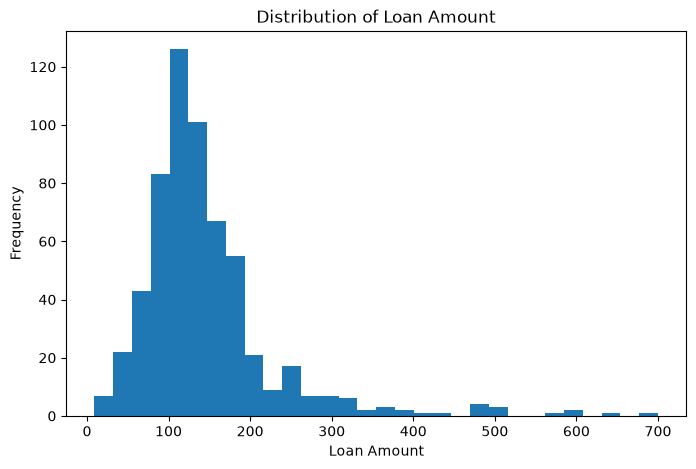

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(data['LoanAmount'].dropna(), bins=30)
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Loan Amount')
plt.show()

### Plan of Action
Based on above observations:

I selected the imputation method for each variable based on its data type, percentage of missing values, and distribution.

* Gender (2.12% missing) → Mode: The missing percentage is low, and one category is clearly more common, so mode is more suitable.
* Married (0.49%) → Mode: Very few values are missing, so simple mode imputation is sufficient.
* Dependents (2.44%) → Mode: The missing percentage is low, and 0 is the most common category.
* Self_Employed (5.21%) → KNN categorical: The missing percentage is higher, and other applicant characteristics may help infer the employment status.
* LoanAmount (3.58%) → Median: The variable is right-skewed and has outliers, so the median is more reliable than the mean.
* Loan_Amount_Term (2.28%) → Median: There are few missing values, and the values are strongly concentrated around 360, making the median appropriate.
* Credit_History (8.14%) → KNN categorical: It has the highest missing percentage, so using other applicant characteristics through KNN may give a better estimate than simply using the mode.


In [55]:
data_og = data.copy()

### Mode imputation

In [56]:
mode_cols = [
    'Gender',
    'Married',
    'Dependents'
]

for col in mode_cols:
    data[col] = data[col].fillna(
        data[col].mode()[0]
    )

In [57]:
print(data[mode_cols].isna().sum())

Gender        0
Married       0
Dependents    0
dtype: int64


### Median imputation

In [58]:
median_cols = [
    'LoanAmount',
    'Loan_Amount_Term'
]

for col in median_cols:
    data[col] = data[col].fillna(
        data[col].median()
    )

In [59]:
print(data[median_cols].isna().sum())

LoanAmount          0
Loan_Amount_Term    0
dtype: int64


In [61]:
# !pip install -U scikit-learn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

knn_cols = ['Self_Employed', 'Credit_History']

exclude_cols = ['Loan_ID', 'Loan_Status'] + knn_cols

# Use all other columns except ID, KNN cols, and Loan_Status
features = [
    col for col in data.columns
    if col not in exclude_cols
]

for target in knn_cols:

    # Rows where target is known/missing
    known = data[data[target].notna()]
    missing = data[data[target].isna()]

    # Convert categorical variables to numerical
    X_known = pd.get_dummies(known[features], drop_first=True)
    X_missing = pd.get_dummies(missing[features], drop_first=True)

    # Make columns identical
    X_missing = X_missing.reindex(
        columns=X_known.columns,
        fill_value=0
    )

    # Scale data for KNN
    scaler = StandardScaler()
    X_known = scaler.fit_transform(X_known)
    X_missing = scaler.transform(X_missing)

    # KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_known, known[target])

    # Predict missing values
    predicted = knn.predict(X_missing)

    # Fill missing values
    data.loc[data[target].isna(), target] = predicted

In [66]:
print(data[knn_cols].isna().sum())

Self_Employed     0
Credit_History    0
dtype: int64
